In [2]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit

import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


In [3]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [6]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


In [8]:
def hybrid_qrnn_loss(y, q_hybrid, sigma_al, alpha):
    """
    Hybrid QRNN ALD NLL Loss
    y        : observed returns (tensor), shape (T,)
    q_hybrid : hybrid quantile estimate (tensor), shape (T,)
    sigma_al : scale parameter (scalar tensor)
    alpha    : quantile level in (0,1)
    """
    u = y - q_hybrid
    indicator  = (u < 0).float()
    rho_alpha  = u * (alpha - indicator)
    nll = (- torch.log(torch.tensor(alpha * (1 - alpha), dtype=torch.float32))
           + torch.log(sigma_al)
           + rho_alpha / sigma_al)
    return nll.mean()


def compute_hybrid_quantile_location_cross_a(y, X, beta1, beta2, beta3, fnn_model, psi):
    """
    Cross-lagged hybrid QRNN location -- A (asymmetric) functional form.
    The CaViaR component uses the previous hybrid output as its autoregressive input.
    A form: q_t = beta1 * q_{t-1}^H + beta2 * y_{t-1}^+ + beta3 * y_{t-1}^-
    y      : raw log returns (T,)
    X      : normalised features (T, input_dim)
    beta1  : quantile persistence, constrained to (0,1)
    beta2  : positive return impact, constrained to >=0
    beta3  : negative return impact, constrained to >=0
    psi    : mixing weight, constrained to (0,1)
    fnn_model : FNN correction network
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)

    q_caviar_list = [torch.zeros(1)]
    q_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        # CaViaR component -- A cross-lagged: uses previous hybrid output
        y_pos    = torch.clamp(y[t-1],  min=0)   # y^+
        y_neg    = torch.clamp(-y[t-1], min=0)   # y^-
        caviar_t = (beta1 * q_hybrid_list[t-1]
                  + beta2 * y_pos
                  + beta3 * y_neg)
        q_caviar_list.append(caviar_t)

        # Hybrid combination
        hybrid_t = psi * caviar_t + (1 - psi) * fnn_out[t]
        q_hybrid_list.append(hybrid_t)

    q_caviar = torch.stack(q_caviar_list).squeeze(-1)
    q_hybrid = torch.stack(q_hybrid_list).squeeze(-1)

    return q_hybrid, q_caviar

In [10]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

# Tuning

In [14]:
class HybridQRNN_A(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))     # y^+ impact
        self.beta3_raw = nn.Parameter(torch.tensor(0.3))     # y^- impact
        self.psi_raw   = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        beta3 = torch.nn.functional.softplus(self.beta3_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        # cross-lagged A: uses previous hybrid output
        q_hybrid, q_caviar = compute_hybrid_quantile_location_cross_a(
            y, X, beta1, beta2, beta3, self.fnn, psi)

        return q_hybrid, sigma


def compute_crp(y, q, alpha):
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective_qrnn(trial, alpha):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridQRNN_A(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        crp, crp_penalty = compute_crp(y_val, q_val, alpha)

        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        beta3 = torch.nn.functional.softplus(model.beta3_raw).item()
        psi   = torch.sigmoid(model.psi_raw).item()
        sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('beta1',       beta1)
    trial.set_user_attr('beta2',       beta2)
    trial.set_user_attr('beta3',       beta3)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"alpha={alpha} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"beta1={beta1:.4f} | beta2={beta2:.4f} | beta3={beta3:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    for rank, t in enumerate(sorted(trials, key=lambda t: t._nll), start=1):
        t._rank_nll = rank

    for rank, t in enumerate(sorted(trials, key=lambda t: t._crp_penalty), start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each alpha level
# -------------------------
alpha_levels               = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed                  = 2026
best_configs_qrnn_a_cross  = {}  # distinct name for QRNN A cross-lagged

for i, alpha in enumerate(alpha_levels):
    print(f"\n{'='*60}")
    print(f"Tuning QRNN A Cross-lagged for alpha = {alpha} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, a=alpha: objective_qrnn(trial, alpha=a),
                   n_trials=200, show_progress_bar=True)

    best_trial, all_trials = select_best_trial_by_rank(study)

    print(f"\nRanking summary for alpha={alpha}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'alpha':       alpha,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'beta1':       t.user_attrs['beta1'],
            'beta2':       t.user_attrs['beta2'],
            'beta3':       t.user_attrs['beta3'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'qrnn_a_cross_ranking_alpha_{alpha}.csv', index=False)
    print(f"  Full ranking saved to qrnn_a_cross_ranking_alpha_{alpha}.csv")

    best_configs_qrnn_a_cross[alpha] = best_trial.params.copy()
    best_configs_qrnn_a_cross[alpha]['alpha'] = alpha

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridQRNN_A(X_train.shape[1], best_configs_qrnn_a_cross[alpha])

    if best_configs_qrnn_a_cross[alpha]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_qrnn_a_cross[alpha]['lr'],
                                     weight_decay=best_configs_qrnn_a_cross[alpha]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_qrnn_a_cross[alpha]['lr'],
                                      weight_decay=best_configs_qrnn_a_cross[alpha]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_qrnn_a_cross[alpha]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            q_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_qrnn_a_cross[alpha].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_qrnn_loss(y_val, q_val_final, sigma_val_final, alpha).item()
        final_crp, final_crp_penalty = compute_crp(y_val, q_val_final, alpha)

        est_beta1 = torch.sigmoid(best_model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(best_model.beta2_raw).item()
        est_beta3 = torch.nn.functional.softplus(best_model.beta3_raw).item()
        est_psi   = torch.sigmoid(best_model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_qrnn_a_cross[alpha]['est_psi']   = est_psi
    best_configs_qrnn_a_cross[alpha]['est_sigma']  = est_sigma
    best_configs_qrnn_a_cross[alpha]['est_beta1']  = est_beta1
    best_configs_qrnn_a_cross[alpha]['est_beta2']  = est_beta2
    best_configs_qrnn_a_cross[alpha]['est_beta3']  = est_beta3
    best_configs_qrnn_a_cross[alpha]['est_crp']    = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank: {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:   {est_psi:.4f}")
    print(f"Estimated sigma: {est_sigma:.4f}")
    print(f"Estimated beta1: {est_beta1:.4f}")
    print(f"Estimated beta2: {est_beta2:.4f}")
    print(f"Estimated beta3: {est_beta3:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE -- QRNN A CROSS-LAGGED")
print("="*60)
for alpha, config in best_configs_qrnn_a_cross.items():
    print(f"alpha={alpha}: {config}")

[I 2026-07-13 23:02:10,648] A new study created in memory with name: no-name-46c6fc70-bc6b-4c10-ba5a-98f7fc6b7528



Tuning QRNN A Cross-lagged for alpha = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=3.6967 | CRP=0.0883 | CRP_penalty=0.8312 | alpha=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5002 | sigma=0.9737 | beta1=0.8001 | beta2=0.8540 | beta3=0.8540
[I 2026-07-13 23:02:14,604] Trial 0 finished with value: 3.6967480182647705 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 3.6967480182647705.
  Trial 1: NLL=3.6843 | CRP=0.0883 | CRP_penalty=0.8312 | alpha=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5070 | sigma=0.9554 | beta1=0.7973 | beta2=0.8496 | beta3=0.8496
[I 2026-07-13 23:02:36,197] Trial 1 finished with value: 3.684284210205078 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'layerno

[I 2026-07-14 00:03:21,214] A new study created in memory with name: no-name-3bcfe911-96a3-404a-b08d-5471a1eb5c3c


...

  Trial 0: NLL=1.8766 | CRP=0.1325 | CRP_penalty=0.7526 | alpha=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5366 | sigma=0.3071 | beta1=0.7524 | beta2=0.6386 | beta3=0.6726
[I 2026-07-14 12:01:21,342] Trial 0 finished with value: 1.876554012298584 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 1.876554012298584.
  Trial 1: NLL=2.1791 | CRP=2.5607 | CRP_penalty=2.4358 | alpha=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5304 | sigma=0.4171 | beta1=0.7660 | beta2=0.6907 | beta3=0.7471
[I 2026-07-14 12:01:40,922] Trial 1 finished with value: 2.1790590286254883 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.04

[I 2026-07-14 13:03:28,217] A new study created in memory with name: no-name-9b50e34a-f2fb-4bb5-b083-16f42a32512e



Best trial (rank-based): #124
  NLL rank: 7 | CRP rank: 3 | Sum: 10
Final NLL:          -2.2464
Final CRP:          1.0155
Final CRP penalty:  0.0002
Best params: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.08675188297618036, 'layernorm': False, 'weight_init': 'he', 'lr': 0.04975921747093399, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.063356060390223e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 107}
Estimated psi:   0.9396
Estimated sigma: 0.0028
Estimated beta1: 0.0530
Estimated beta2: 0.0932
Estimated beta3: 0.1242

Tuning QRNN A Cross-lagged for alpha = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=2.4777 | CRP=0.3532 | CRP_penalty=0.4183 | alpha=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5118 | sigma=0.2887 | beta1=0.7614 | beta2=0.6036 | beta3=0.6408
[I 2026-07-14 13:03:49,364] Trial 0 finished with value: 2.477735996246338 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 2.477735996246338.
  Trial 1: NLL=3.6766 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5029 | sigma=0.9560 | beta1=0.7986 | beta2=0.8567 | beta3=0.8582
[I 2026-07-14 13:04:08,865] Trial 1 finished with value: 3.67661452293396 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 


Training final model for alpha = 0.025 (A cross-lagged)
  Epoch 50: train=2.0127, val=1.9585
  Epoch 100: train=-0.1411, val=-0.1830
  Epoch 150: train=-1.4636, val=-1.6635
  Early stopping at epoch 199
  Test loss: -2.2481 | Coverage ratio: 0.705 | beta1=0.0396 | beta2=0.0615 | beta3=0.1952 | psi=0.9556 | sigma=0.0017

Training final model for alpha = 0.05 (A cross-lagged)
  Epoch 50: train=1.1166, val=1.0538
  Epoch 100: train=-0.9949, val=-1.2954
  Epoch 150: train=-1.9458, val=-2.0986
  Epoch 200: train=-2.0970, val=-2.3125
  Test loss: -2.3903 | Coverage ratio: 2.731 | beta1=0.0555 | beta2=0.0384 | beta3=0.1540 | psi=0.9881 | sigma=0.0025

Training final model for alpha = 0.25 (A cross-lagged)
  Epoch 50: train=0.4490, val=0.4098
  Epoch 100: train=-1.6570, val=-1.8294
  Epoch 150: train=-1.8730, val=-2.1356
  Epoch 200: train=-2.3261, val=-2.4013
  Test loss: -2.5304 | Coverage ratio: 0.714 | beta1=0.0823 | beta2=0.0252 | beta3=0.0928 | psi=0.9764 | sigma=0.0082

Training final 

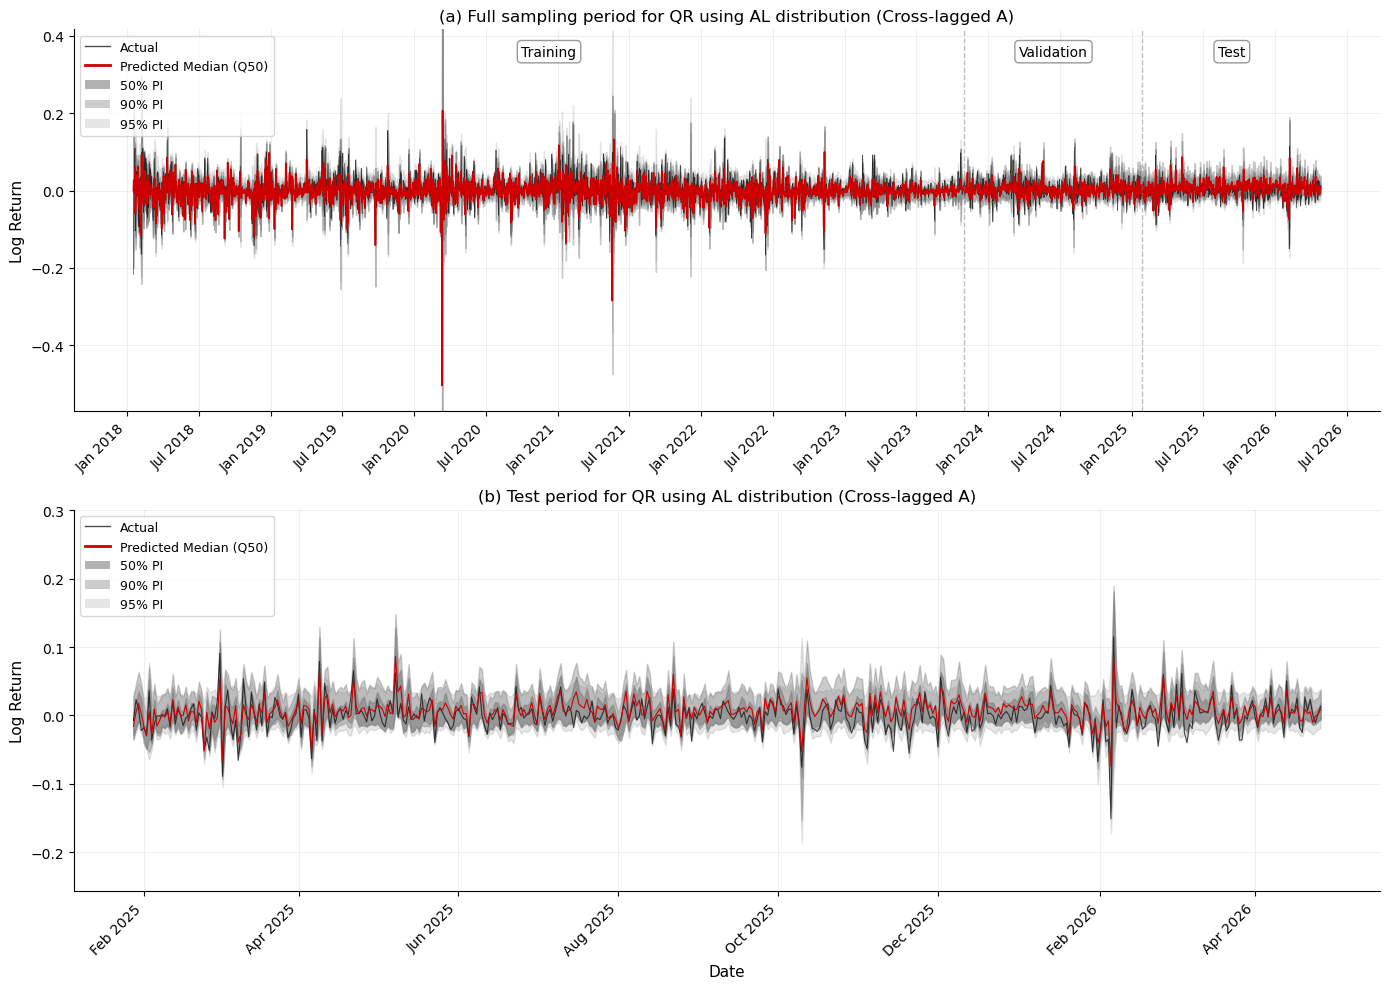

Full period plot saved to hybrid_qrnn_cross_a_predictions_full.png
Test period plot saved to hybrid_qrnn_cross_a_predictions_test.png

CROSSOVER ANALYSIS -- QRNN Cross A (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):           0      0.00% <-- TAIL
  (0.050, 0.250):         212     46.70%
  (0.250, 0.500):           1      0.22%
  (0.500, 0.750):           2      0.44%
  (0.750, 0.950):           0      0.00%
  (0.950, 0.975):         257     56.61% <-- TAIL
  ------------------------------------------
  Total violations:         472  (17.33% of all pairs)
  Tail violations:          257  (28.30% of tail pairs)

TEST SET METRICS -- QRNN A Cross-lagged
   alpha        NLL            HRE
  ----------------------------------
   0.025    -2.2481       0.007379
    0.05    -2.3903       0.086564
    0.25    -2.5304       0.071586
     0.5    -2.6827       0.226872
    0.75    -2.4968       0.194934
    0.95    -

In [16]:
def train_final_model_qrnn_a(alpha, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridQRNN_A(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        q_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha)

        if alpha <= 0.5:
            coverage = (y_test <= q_test).float().mean().item()
        else:
            coverage = (y_test > q_test).float().mean().item()
        expected       = alpha if alpha <= 0.5 else 1 - alpha
        coverage_ratio = coverage / expected

    with torch.no_grad():
        est_beta1 = torch.sigmoid(model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        est_beta3 = torch.nn.functional.softplus(model.beta3_raw).item()
        est_psi   = torch.sigmoid(model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | Coverage ratio: {coverage_ratio:.3f} | "
          f"beta1={est_beta1:.4f} | beta2={est_beta2:.4f} | beta3={est_beta3:.4f} | "
          f"psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'qrnn_a_cross_history_alpha_{alpha}.csv', index=False)

    return model, train_losses, val_losses, q_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all alpha levels
# -------------------------
alpha_levels           = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_qrnn_a_cross   = {}

for alpha in alpha_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for alpha = {alpha} (A cross-lagged)")
    print(f"{'='*60}")
    config = best_configs_qrnn_a_cross[alpha]
    model, train_losses, val_losses, q_test_pred = train_final_model_qrnn_a(
        alpha, config, y_train, X_train, y_val, X_val, y_test_q, X_test_q
    )
    results_qrnn_a_cross[alpha] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'q_test':       q_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols,
                        title_suffix='QR using AL distribution (Cross-lagged A)',
                        save_fname='hybrid_qrnn_cross_a_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    alpha_levels = list(best_configs_qrnn_a_cross.keys())

    for alpha in alpha_levels:
        model = results_qrnn[alpha]['model']
        model.eval()
        with torch.no_grad():
            q_all, _ = model(y_all, X_all)
            all_preds[alpha] = q_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    y_min, y_max     = y_all_np.min(), y_all_np.max()
    y_range          = y_max - y_min
    y_label          = y_max + 0.25 * y_range
    test_dates       = test_df.index
    y_test_np        = test_df['log_return'].values
    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t        = y_max_t - y_min_t

    # ============================================================
    # Combined two-panel figure
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=0.8)
    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_fname}")
    plt.show()
    plt.close()

    # ============================================================
    # Panel (a) -- full period separately
    # ============================================================
    fig_a, ax_a = plt.subplots(1, 1, figsize=(14, 5))
    ax_a.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax_a.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax_a.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax_a.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax_a.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax_a.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax_a.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.text(train_df.index[len(train_df)//2], y_label, 'Training',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(val_df.index[len(val_df)//2], y_label, 'Validation',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(test_df.index[len(test_df)//2], y_label, 'Test',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_a.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_a.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax_a.set_ylabel('Log Return', fontsize=11)
    ax_a.grid(True, alpha=0.2)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    fname_a = save_fname.replace('.png', '_full.png')
    plt.tight_layout()
    plt.savefig(fname_a, dpi=300, bbox_inches='tight')
    print(f"Full period plot saved to {fname_a}")
    plt.close()

    # ============================================================
    # Panel (b) -- test period separately
    # ============================================================
    fig_b, ax_b = plt.subplots(1, 1, figsize=(14, 5))
    ax_b.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax_b.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax_b.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=0.8)
    if have_95:
        ax_b.fill_between(test_dates,
                          all_preds[0.025][train_size + val_size:],
                          all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax_b.fill_between(test_dates,
                          all_preds[0.05][train_size + val_size:],
                          all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax_b.fill_between(test_dates,
                          all_preds[0.25][train_size + val_size:],
                          all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_b.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_b.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax_b.set_xlabel('Date', fontsize=11)
    ax_b.set_ylabel('Log Return', fontsize=11)
    ax_b.grid(True, alpha=0.2)
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    fname_b = save_fname.replace('.png', '_test.png')
    plt.tight_layout()
    plt.savefig(fname_b, dpi=300, bbox_inches='tight')
    print(f"Test period plot saved to {fname_b}")
    plt.close()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- A cross-lagged
# -------------------------
all_preds_qrnn_a_cross, train_size, val_size = plot_two_panel_qrnn(
    results_qrnn_a_cross, train_df, val_df, test_df, feature_cols,
    title_suffix='QR using AL distribution (Cross-lagged A)',
    save_fname='hybrid_qrnn_cross_a_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='QRNN'):
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]
    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


def compute_hre(y_true, q_pred, alpha):
    y        = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    q        = q_pred if isinstance(q_pred, np.ndarray) else np.array(q_pred)
    hit_rate = np.mean(q > y)
    hre      = np.abs(hit_rate - alpha)
    return hre


def compute_test_metrics_qrnn(results, alpha_levels, y_test, X_test, model_name='QRNN'):
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'alpha':>6} {'NLL':>10} {'HRE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    hre_list = []

    for alpha in alpha_levels:
        model = results[alpha]['model']
        model.eval()

        with torch.no_grad():
            q_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha).item()

        q_test_np = q_test.numpy()
        y_test_np = y_test.numpy()

        hre = compute_hre(y_test_np, q_test_np, alpha)

        nll_list.append(test_nll)
        hre_list.append(hre)

        print(f"  {alpha:>6} {test_nll:>10.4f} {hre:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(hre_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average HRE: {np.mean(hre_list):.6f}")

    return np.mean(nll_list), np.mean(hre_list)


total_viol, tail_viol = compute_crossovers(
    all_preds_qrnn_a_cross, alpha_levels, train_size, val_size,
    model_name='QRNN Cross A'
)

avg_nll_qrnn_a_cross, avg_hre_qrnn_a_cross = compute_test_metrics_qrnn(
    results_qrnn_a_cross, alpha_levels, y_test_q, X_test_q,
    model_name='QRNN A Cross-lagged'
)

# Cross over dealing

In [19]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Joint QRNN A Cross-lagged
# One model estimates all seven quantile levels
# ============================================================

alpha_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]


class HybridQRNN_A_Cross_Joint(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(alpha_levels)
        self.eps = 1e-6

        # Seven level-specific parameter sets
        self.beta1_raw = nn.Parameter(
            torch.full((self.n_levels,), 1.386)
        )
        self.beta2_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.beta3_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.psi_raw = nn.Parameter(
            torch.zeros(self.n_levels)
        )
        self.sigma_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.5)
        )

        # Shared FNN
        layers = []
        prev_dim = input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(config['dropout'])
                )

            prev_dim = hidden_dim

        # Median plus six raw spacings
        layers.append(
            nn.Linear(prev_dim, self.n_levels)
        )

        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def reconstruct_fnn_quantiles(self, raw_fnn):
        median = raw_fnn[:, 0]
        delta = (
            F.softplus(raw_fnn[:, 1:])
            + self.eps
        )

        f4 = median

        f3 = f4 - delta[:, 2]
        f2 = f3 - delta[:, 1]
        f1 = f2 - delta[:, 0]

        f5 = f4 + delta[:, 3]
        f6 = f5 + delta[:, 4]
        f7 = f6 + delta[:, 5]

        return torch.stack(
            [f1, f2, f3, f4, f5, f6, f7],
            dim=1
        )

    def forward(
        self,
        y,
        X,
        initial_hybrid=None,
        initial_y=None
    ):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        beta3 = F.softplus(self.beta3_raw)
        psi = torch.sigmoid(self.psi_raw)
        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        raw_fnn = self.fnn(X)
        fnn_quantiles = (
            self.reconstruct_fnn_quantiles(
                raw_fnn
            )
        )

        q_hybrid, q_caviar = (
            compute_hybrid_location_cross_a_joint(
                y=y,
                fnn_quantiles=fnn_quantiles,
                beta1=beta1,
                beta2=beta2,
                beta3=beta3,
                psi=psi,
                initial_hybrid=initial_hybrid,
                initial_y=initial_y
            )
        )

        return (
            q_hybrid,
            sigma,
            q_caviar,
            fnn_quantiles
        )


def compute_hybrid_location_cross_a_joint(
    y,
    fnn_quantiles,
    beta1,
    beta2,
    beta3,
    psi,
    initial_hybrid=None,
    initial_y=None
):
    """
    Cross-lagged asymmetric recursion:

    q^S_{k,t}
    = beta1_k q^H_{k,t-1}
    + beta2_k y^+_{t-1}
    + beta3_k y^-_{t-1}

    q^H_{k,t}
    = psi_k q^S_{k,t}
    + (1-psi_k) f_{k,t}
    """
    T = len(y)
    n_levels = fnn_quantiles.shape[1]
    zero_row = y.new_zeros(n_levels)

    q_hybrid_list = []
    q_caviar_list = []

    has_initial_state = (
        initial_hybrid is not None
        and initial_y is not None
    )

    if (
        (initial_hybrid is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_hybrid and initial_y '
            'must be supplied together.'
        )

    previous_hybrid = (
        initial_hybrid
        if has_initial_state
        else zero_row
    )

    for t in range(T):
        if t == 0 and not has_initial_state:
            q_caviar_list.append(zero_row)
            q_hybrid_list.append(zero_row)
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        y_pos = torch.clamp(
            previous_y,
            min=0
        )
        y_neg = torch.clamp(
            -previous_y,
            min=0
        )

        caviar_t = (
            beta1 * previous_hybrid
            + beta2 * y_pos
            + beta3 * y_neg
        )

        hybrid_t = (
            psi * caviar_t
            + (1 - psi) * fnn_quantiles[t]
        )

        q_caviar_list.append(caviar_t)
        q_hybrid_list.append(hybrid_t)

        # Cross-lagged: use previous hybrid output
        previous_hybrid = hybrid_t

    q_caviar = torch.stack(
        q_caviar_list,
        dim=0
    )
    q_hybrid = torch.stack(
        q_hybrid_list,
        dim=0
    )

    return q_hybrid, q_caviar


# ============================================================
# Joint loss and evaluation metrics
# ============================================================

def hybrid_qrnn_joint_loss(
    y,
    q_hybrid,
    sigma,
    levels=alpha_levels
):
    alpha = torch.tensor(
        levels,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    u = y.unsqueeze(1) - q_hybrid
    indicator = (u < 0).float()
    rho = u * (
        alpha.unsqueeze(0) - indicator
    )

    nll = (
        -torch.log(
            alpha * (1 - alpha)
        ).unsqueeze(0)
        + torch.log(sigma).unsqueeze(0)
        + rho / sigma.unsqueeze(0)
    )

    return nll.mean()


def compute_hre_joint(
    y,
    q_hybrid,
    levels=alpha_levels
):
    alpha = torch.tensor(
        levels,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    hit_rate = (
        y.unsqueeze(1) <= q_hybrid
    ).float().mean(dim=0)

    hre = torch.abs(
        hit_rate - alpha
    )

    return hre, hre.mean()


def compute_crossover_joint(q_hybrid):
    violations = (
        q_hybrid[:, :-1]
        > q_hybrid[:, 1:]
    )

    pair_counts = violations.sum(dim=0)
    T = len(q_hybrid)

    total_count = int(
        pair_counts.sum().item()
    )
    total_rate = total_count / (T * 6)

    tail_count = int(
        pair_counts[0].item()
        + pair_counts[-1].item()
    )
    tail_rate = tail_count / (T * 2)

    return {
        'pair_counts': [
            int(x)
            for x in pair_counts.tolist()
        ],
        'total_count': total_count,
        'total_rate': total_rate,
        'tail_count': tail_count,
        'tail_rate': tail_rate
    }


# ============================================================
# Fit one joint model
# ============================================================

def fit_joint_qrnn_cross(
    config,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = HybridQRNN_A_Cross_Joint(
        X_train.shape[1],
        config
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        q_train, sigma, _, _ = model(
            y_train,
            X_train
        )

        # t=0 is only the initialisation row
        train_loss = hybrid_qrnn_joint_loss(
            y_train[1:],
            q_train[1:],
            sigma
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        # Continue validation from training state
        model.eval()
        with torch.no_grad():
            q_train_state, sigma_val, _, _ = model(
                y_train,
                X_train
            )

            q_val, _, _, _ = model(
                y_val,
                X_val,
                initial_hybrid=q_train_state[-1],
                initial_y=y_train[-1]
            )

            val_loss = hybrid_qrnn_joint_loss(
                y_val,
                q_val,
                sigma_val
            )

        scheduler.step(
            val_loss.item()
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


def evaluate_joint_qrnn_cross(model):
    model.eval()

    with torch.no_grad():
        q_train, sigma, _, _ = model(
            y_train,
            X_train
        )

        q_val, _, _, fnn_val = model(
            y_val,
            X_val,
            initial_hybrid=q_train[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_qrnn_joint_loss(
            y_val,
            q_val,
            sigma
        ).item()

        hre_levels, mean_hre = (
            compute_hre_joint(
                y_val,
                q_val
            )
        )

        final_cross = (
            compute_crossover_joint(q_val)
        )
        fnn_cross = (
            compute_crossover_joint(fnn_val)
        )

        beta1 = torch.sigmoid(
            model.beta1_raw
        )
        beta2 = F.softplus(
            model.beta2_raw
        )
        beta3 = F.softplus(
            model.beta3_raw
        )
        psi = torch.sigmoid(
            model.psi_raw
        )
        sigma = (
            F.softplus(model.sigma_raw)
            + model.eps
        )

    return {
        'mean_nll': mean_nll,
        'hre_by_level': hre_levels.tolist(),
        'mean_hre': mean_hre.item(),
        'final_crossover': final_cross,
        'fnn_crossover': fnn_cross,
        'beta1': beta1.tolist(),
        'beta2': beta2.tolist(),
        'beta3': beta3.tolist(),
        'psi': psi.tolist(),
        'sigma': sigma.tolist()
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_qrnn_cross_joint(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    model = fit_joint_qrnn_cross(
        config=config,
        max_epochs=200,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_qrnn_cross(
        model
    )

    for name in [
        'mean_nll',
        'mean_hre',
        'hre_by_level',
        'beta1',
        'beta2',
        'beta3',
        'psi',
        'sigma'
    ]:
        trial.set_user_attr(
            name,
            metrics[name]
        )

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )
    trial.set_user_attr(
        'fnn_crossover_count',
        metrics['fnn_crossover']['total_count']
    )

    print(
        f"Trial {trial.number}: "
        f"NLL={metrics['mean_nll']:.6f} | "
        f"HRE={metrics['mean_hre']:.6f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%} | "
        f"FNN crossover="
        f"{metrics['fnn_crossover']['total_rate']:.2%}"
    )

    # Trial search is guided by validation NLL.
    # Final selection uses NLL rank + HRE rank.
    return metrics['mean_nll']


# ============================================================
# Rank by validation NLL and HRE
# ============================================================

def select_best_trial_by_rank_joint(study):
    trials = [
        t for t in study.trials
        if (
            t.state
            == optuna.trial.TrialState.COMPLETE
            and t.value is not None
            and np.isfinite(t.value)
            and 'mean_nll' in t.user_attrs
            and 'mean_hre' in t.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for t in trials:
        t._nll = t.user_attrs['mean_nll']
        t._hre = t.user_attrs['mean_hre']

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._nll
        ),
        start=1
    ):
        t._rank_nll = rank

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._hre
        ),
        start=1
    ):
        t._rank_hre = rank

    best = min(
        trials,
        key=lambda t: (
            t._rank_nll + t._rank_hre,
            t._nll,
            t._hre,
            t.number
        )
    )

    return best, trials


# ============================================================
# Run one 800-trial joint study
# ============================================================

print('\n' + '=' * 70)
print(
    'Tuning Joint QRNN A Cross-lagged '
    'for all seven alpha levels'
)
print('=' * 70)

sampler = TPESampler(seed=2026)

study_qrnn_a_cross_joint = (
    optuna.create_study(
        direction='minimize',
        sampler=sampler
    )
)

study_qrnn_a_cross_joint.optimize(
    objective_qrnn_cross_joint,
    n_trials=800,
    show_progress_bar=True
)

best_trial_cross, all_trials_cross = (
    select_best_trial_by_rank_joint(
        study_qrnn_a_cross_joint
    )
)


# ============================================================
# Save trial ranking
# ============================================================

ranking_records = []

for t in all_trials_cross:
    record = {
        'trial': t.number,
        'mean_nll': t._nll,
        'mean_hre': t._hre,
        'rank_nll': t._rank_nll,
        'rank_hre': t._rank_hre,
        'sum_rank': (
            t._rank_nll + t._rank_hre
        ),
        'final_crossover_count':
            t.user_attrs[
                'final_crossover_count'
            ],
        'final_crossover_rate':
            t.user_attrs[
                'final_crossover_rate'
            ],
        'tail_crossover_count':
            t.user_attrs[
                'tail_crossover_count'
            ],
        'tail_crossover_rate':
            t.user_attrs[
                'tail_crossover_rate'
            ],
        'fnn_crossover_count':
            t.user_attrs[
                'fnn_crossover_count'
            ]
    }

    for k, alpha in enumerate(alpha_levels):
        suffix = f'alpha_{alpha}'

        record[f'hre_{suffix}'] = (
            t.user_attrs['hre_by_level'][k]
        )
        record[f'beta1_{suffix}'] = (
            t.user_attrs['beta1'][k]
        )
        record[f'beta2_{suffix}'] = (
            t.user_attrs['beta2'][k]
        )
        record[f'beta3_{suffix}'] = (
            t.user_attrs['beta3'][k]
        )
        record[f'psi_{suffix}'] = (
            t.user_attrs['psi'][k]
        )
        record[f'sigma_{suffix}'] = (
            t.user_attrs['sigma'][k]
        )

    record.update(t.params)
    ranking_records.append(record)


ranking_df_cross = pd.DataFrame(
    ranking_records
)

ranking_df_cross = (
    ranking_df_cross.sort_values(
        ['sum_rank', 'mean_nll', 'mean_hre']
    )
)

ranking_df_cross.to_csv(
    'joint_qrnn_a_cross_ranking.csv',
    index=False
)


# ============================================================
# Refit and save selected model
# ============================================================

best_config_cross = (
    best_trial_cross.params.copy()
)

best_model_cross_joint = (
    fit_joint_qrnn_cross(
        config=best_config_cross,
        max_epochs=200,
        seed=2026
    )
)

best_metrics_cross_joint = (
    evaluate_joint_qrnn_cross(
        best_model_cross_joint
    )
)

torch.save(
    {
        'model_state_dict':
            best_model_cross_joint.state_dict(),
        'config':
            best_config_cross,
        'alpha_levels':
            alpha_levels,
        'validation_metrics':
            best_metrics_cross_joint
    },
    'joint_qrnn_a_cross_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

print('\n' + '=' * 70)
print('TUNING COMPLETE -- JOINT QRNN A CROSS-LAGGED')
print('=' * 70)
print(
    f'Best trial: {best_trial_cross.number}'
)
print(
    f"Validation NLL: "
    f"{best_metrics_cross_joint['mean_nll']:.6f}"
)
print(
    f"Validation HRE: "
    f"{best_metrics_cross_joint['mean_hre']:.6f}"
)
print(
    f"Final hybrid crossover: "
    f"{best_metrics_cross_joint['final_crossover']['total_count']} "
    f"("
    f"{best_metrics_cross_joint['final_crossover']['total_rate']:.2%}"
    f")"
)
print(
    f"Tail crossover: "
    f"{best_metrics_cross_joint['final_crossover']['tail_count']} "
    f"("
    f"{best_metrics_cross_joint['final_crossover']['tail_rate']:.2%}"
    f")"
)
print(
    f"FNN crossover count: "
    f"{best_metrics_cross_joint['fnn_crossover']['total_count']}"
)
print(
    f'Best architecture: {best_config_cross}'
)

[I 2026-07-26 15:58:49,407] A new study created in memory with name: no-name-85d50137-3da1-4e18-8d72-9a048741e214



Tuning Joint QRNN A Cross-lagged for all seven alpha levels


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=2.514124 | HRE=0.068259 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-26 15:59:13,641] Trial 0 finished with value: 2.5141239166259766 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.5141239166259766.
Trial 1: NLL=1.471803 | HRE=0.030416 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-26 15:59:38,698] Trial 1 finished with value: 1.4718027114868164 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 1.4718027114868164.
Trial 2: NLL=2.610056 |

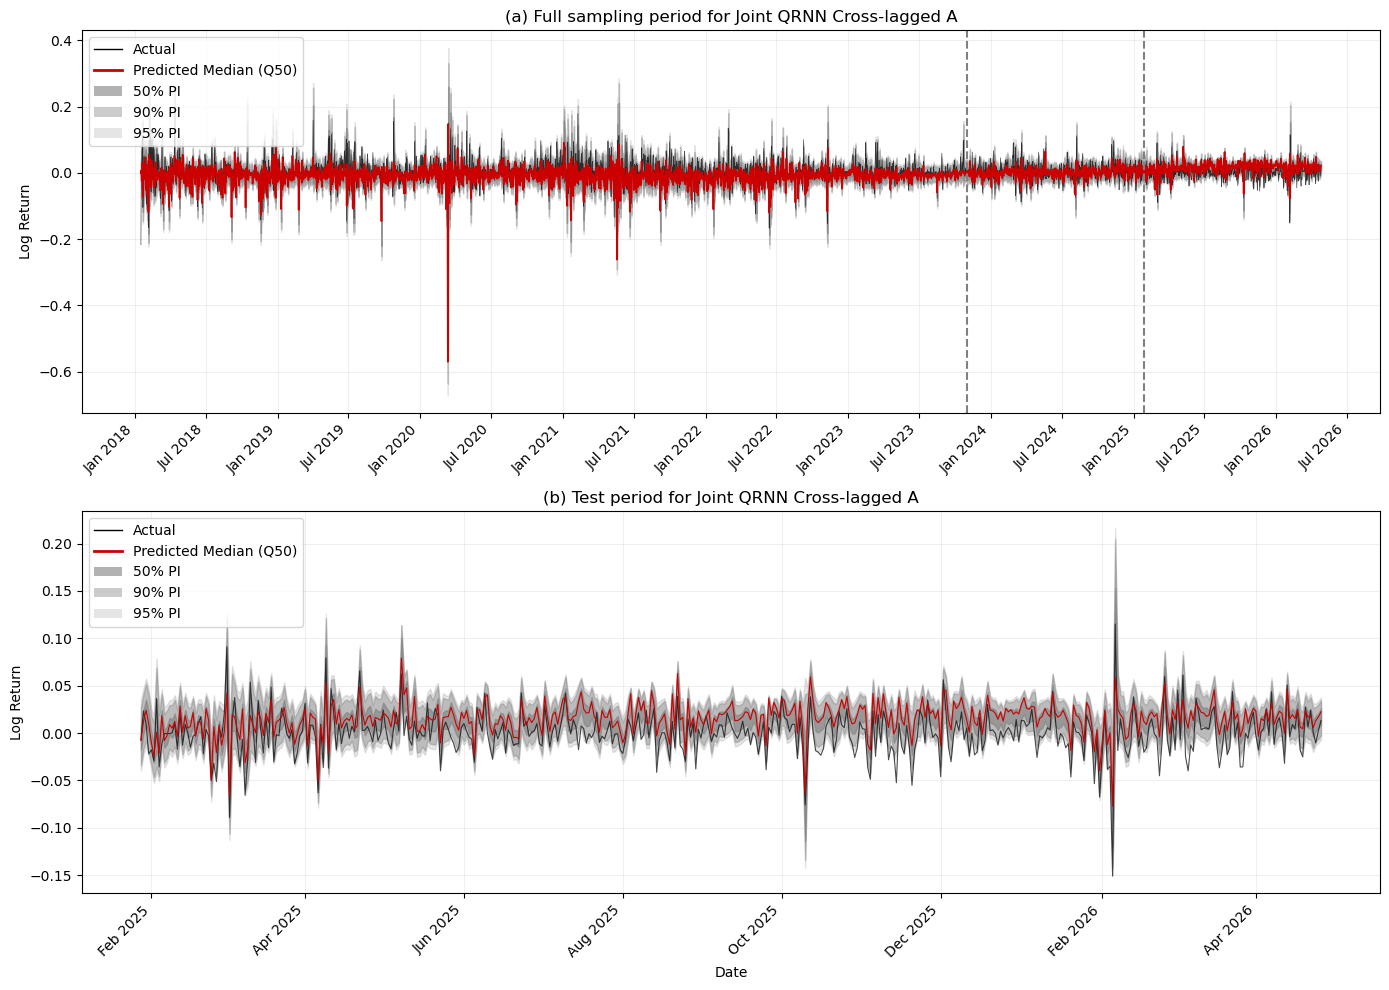

Plot saved to hybrid_qrnn_cross_a_joint_predictions.png

TEST METRICS -- JOINT QRNN A CROSS-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -1.962603  0.151982 0.126982
 0.050 -2.029444  0.270925 0.220925
 0.250 -2.341575  0.640969 0.390969
 0.500 -2.307242  0.883260 0.383260
 0.750 -2.437336  0.955947 0.205947
 0.950 -2.210691  1.000000 0.050000
 0.975 -2.077371  1.000000 0.025000

Average NLL: -2.195180
Average HRE: 0.200441

CROSSOVER ANALYSIS -- FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 13 (2.86%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 13 (0.48%)
Tail violations: 0 (0.00%)

CROSSOVER ANALYSIS -- MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)


In [22]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# Joint QRNN A Cross-lagged -- plotting and test evaluation
# Run directly after the cross-lagged tuning code
# ============================================================

X_test_q = torch.tensor(
    test_df[feature_cols].values,
    dtype=torch.float32
)
y_test_q = torch.tensor(
    test_df['log_return'].values,
    dtype=torch.float32
)

model = best_model_cross_joint
model.eval()


# -------------------------
# Sequential predictions
# -------------------------
with torch.no_grad():
    q_train, sigma, _, fnn_train = model(
        y_train,
        X_train
    )

    q_val, _, _, fnn_val = model(
        y_val,
        X_val,
        initial_hybrid=q_train[-1],
        initial_y=y_train[-1]
    )

    q_test, _, _, fnn_test = model(
        y_test_q,
        X_test_q,
        initial_hybrid=q_val[-1],
        initial_y=y_val[-1]
    )

q_train_np = q_train.numpy()
q_val_np   = q_val.numpy()
q_test_np  = q_test.numpy()

q_all = np.concatenate(
    [q_train_np, q_val_np, q_test_np],
    axis=0
)

y_all = np.concatenate([
    train_df['log_return'].values,
    val_df['log_return'].values,
    test_df['log_return'].values
])

all_dates = (
    train_df.index
    .append(val_df.index)
    .append(test_df.index)
)

all_preds_qrnn_a_cross = {
    alpha: q_all[:, k]
    for k, alpha in enumerate(alpha_levels)
}


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_qrnn_joint(
    all_preds,
    train_df,
    val_df,
    test_df,
    save_fname='hybrid_qrnn_cross_a_joint_predictions.png'
):
    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    train_size = len(train_df)
    val_size   = len(val_df)
    test_start = train_size + val_size

    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    legend_elements = [
        Line2D(
            [0], [0],
            color=actual_color,
            lw=1,
            label='Actual'
        ),
        Line2D(
            [0], [0],
            color=pred_color,
            lw=2,
            label='Predicted Median (Q50)'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.6,
            label='50% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.4,
            label='90% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.2,
            label='95% PI'
        )
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10)
    )

    # -------------------------
    # Full sample
    # -------------------------
    ax = axes[0]

    ax.plot(
        all_dates,
        y_all,
        color=actual_color,
        linewidth=0.5,
        alpha=0.7
    )
    ax.plot(
        all_dates,
        all_preds[0.500],
        color=pred_color,
        linewidth=1.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.025],
        all_preds[0.975],
        color=pi_color,
        alpha=0.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.050],
        all_preds[0.950],
        color=pi_color,
        alpha=0.4
    )
    ax.fill_between(
        all_dates,
        all_preds[0.250],
        all_preds[0.750],
        color=pi_color,
        alpha=0.6
    )

    ax.axvline(
        train_df.index[-1],
        color='gray',
        linestyle='--'
    )
    ax.axvline(
        val_df.index[-1],
        color='gray',
        linestyle='--'
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=6)
    )
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_title(
        '(a) Full sampling period for '
        'Joint QRNN Cross-lagged A'
    )
    ax.set_ylabel('Log Return')
    ax.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax.grid(True, alpha=0.2)

    # -------------------------
    # Test sample
    # -------------------------
    ax2 = axes[1]

    ax2.plot(
        test_dates,
        y_test_np,
        color=actual_color,
        linewidth=0.8,
        alpha=0.7
    )
    ax2.plot(
        test_dates,
        all_preds[0.500][test_start:],
        color=pred_color,
        linewidth=0.8
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.025][test_start:],
        all_preds[0.975][test_start:],
        color=pi_color,
        alpha=0.2
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.050][test_start:],
        all_preds[0.950][test_start:],
        color=pi_color,
        alpha=0.4
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.250][test_start:],
        all_preds[0.750][test_start:],
        color=pi_color,
        alpha=0.6
    )

    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax2.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )
    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax2.set_title(
        '(b) Test period for '
        'Joint QRNN Cross-lagged A'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log Return')
    ax2.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        save_fname,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(f'Plot saved to {save_fname}')


plot_two_panel_qrnn_joint(
    all_preds_qrnn_a_cross,
    train_df,
    val_df,
    test_df
)


# ============================================================
# Test NLL and HRE
# ============================================================
def compute_test_metrics_joint(
    y_test,
    q_test,
    sigma,
    alpha_levels
):
    records = []

    for k, alpha in enumerate(alpha_levels):
        y = y_test
        q = q_test[:, k]
        sigma_k = sigma[k]

        u = y - q
        indicator = (u < 0).float()
        rho = u * (alpha - indicator)

        nll = (
            -np.log(alpha * (1 - alpha))
            + torch.log(sigma_k)
            + rho / sigma_k
        ).mean().item()

        hit_rate = (
            y <= q
        ).float().mean().item()

        hre = abs(hit_rate - alpha)

        records.append({
            'alpha': alpha,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': hre
        })

    results = pd.DataFrame(records)

    print('\n' + '=' * 60)
    print('TEST METRICS -- JOINT QRNN A CROSS-LAGGED')
    print('=' * 60)
    print(results.to_string(index=False))
    print(f"\nAverage NLL: {results['NLL'].mean():.6f}")
    print(f"Average HRE: {results['HRE'].mean():.6f}")

    results.to_csv(
        'joint_qrnn_a_cross_test_metrics.csv',
        index=False
    )

    return results


test_metrics_qrnn_a_cross = compute_test_metrics_joint(
    y_test_q,
    q_test,
    sigma,
    alpha_levels
)


# ============================================================
# Test crossover analysis
# ============================================================
def compute_crossovers_joint(
    q_pred,
    levels,
    model_name
):
    q = q_pred.numpy()
    T = len(q)

    total_violations = 0
    tail_violations  = 0

    print('\n' + '=' * 60)
    print(f'CROSSOVER ANALYSIS -- {model_name}')
    print('=' * 60)

    for k in range(len(levels) - 1):
        lo = levels[k]
        hi = levels[k + 1]

        violations = int(
            np.sum(q[:, k] > q[:, k + 1])
        )
        percentage = violations / T * 100

        total_violations += violations

        if k == 0 or k == len(levels) - 2:
            tail_violations += violations
            marker = ' <-- TAIL'
        else:
            marker = ''

        print(
            f'({lo:.3f}, {hi:.3f}): '
            f'{violations} ({percentage:.2f}%){marker}'
        )

    total_rate = (
        total_violations /
        (T * (len(levels) - 1))
    )
    tail_rate = tail_violations / (T * 2)

    print(
        f'\nTotal violations: {total_violations} '
        f'({total_rate:.2%})'
    )
    print(
        f'Tail violations: {tail_violations} '
        f'({tail_rate:.2%})'
    )

    return total_violations, tail_violations


# Final hybrid forecasts: crossing may remain
final_crossovers = compute_crossovers_joint(
    q_test,
    alpha_levels,
    'FINAL HYBRID OUTPUT'
)

# FNN forecasts: crossing should be zero
fnn_crossovers = compute_crossovers_joint(
    fnn_test,
    alpha_levels,
    'MONOTONIC FNN OUTPUT'
)

# Cross over dealing 2

In [29]:
# ============================================================
# METHOD 2 — SEQUENTIAL HYBRID QRNN A CROSS-LAGGED
# 200 trials per level
# Selection by validation NLL rank + HRE rank
# ============================================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna

from optuna.samplers import TPESampler


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

m2_cross_alpha_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

m2_cross_estimation_order = [
    0.500,
    0.750,
    0.950,
    0.975,
    0.250,
    0.050,
    0.025
]

m2_cross_reference_level = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050
}

m2_cross_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower'
}

M2_CROSS_DELTA = 1e-6
M2_CROSS_SMOOTH_A = 1e-3
M2_CROSS_PSI_MARGIN = 1e-4

M2_CROSS_N_TRIALS = 200
M2_CROSS_MAX_EPOCHS = 200
M2_CROSS_BASE_SEED = 2026


# ------------------------------------------------------------
# Scaled softplus
# ------------------------------------------------------------

def m2_cross_scaled_softplus(x):

    return (
        M2_CROSS_SMOOTH_A
        * F.softplus(
            x / M2_CROSS_SMOOTH_A
        )
    )


# ------------------------------------------------------------
# Sequential QRNN A Cross-lagged model
# ------------------------------------------------------------

class M2SequentialQRNNCrossA(nn.Module):

    def __init__(
        self,
        input_dim,
        config,
        direction=None
    ):
        super().__init__()

        self.direction = direction

        self.beta1_raw = nn.Parameter(
            torch.tensor(1.386)
        )

        self.beta2_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.beta3_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )

        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        # Non-median models receive the reference
        # forecast as one additional FNN input.
        fnn_input_dim = (
            input_dim
            if direction is None
            else input_dim + 1
        )

        layers = []
        prev_dim = fnn_input_dim

        for i in range(
            config['n_hidden_layers']
        ):

            hidden_dim = config[
                f'hidden_dim_{i}'
            ]

            layers.append(
                nn.Linear(
                    prev_dim,
                    hidden_dim
                )
            )

            if config['layernorm']:

                layers.append(
                    nn.LayerNorm(
                        hidden_dim
                    )
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:

                layers.append(
                    nn.Dropout(
                        config['dropout']
                    )
                )

            prev_dim = hidden_dim

        layers.append(
            nn.Linear(prev_dim, 1)
        )

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():

            if isinstance(
                module,
                nn.Linear
            ):

                if (
                    config['weight_init']
                    == 'glorot'
                ):

                    nn.init.xavier_uniform_(
                        module.weight
                    )

                elif (
                    config['weight_init']
                    == 'he'
                ):

                    nn.init.kaiming_uniform_(
                        module.weight
                    )

                if module.bias is not None:

                    nn.init.zeros_(
                        module.bias
                    )


    def _get_activation(self, name):

        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())


    def constrain_fnn(
        self,
        f_raw,
        caviar,
        q_reference,
        psi
    ):

        denominator = 1.0 - psi

        if self.direction == 'upper':

            fnn_boundary = (
                q_reference
                + M2_CROSS_DELTA
                - psi * caviar
            ) / denominator

            f_constrained = (
                fnn_boundary
                + m2_cross_scaled_softplus(
                    f_raw - fnn_boundary
                )
            )

        elif self.direction == 'lower':

            fnn_boundary = (
                q_reference
                - M2_CROSS_DELTA
                - psi * caviar
            ) / denominator

            f_constrained = (
                fnn_boundary
                - m2_cross_scaled_softplus(
                    fnn_boundary - f_raw
                )
            )

        else:

            f_constrained = f_raw

        return f_constrained


    def forward(
        self,
        y,
        X,
        q_reference=None,
        initial_hybrid=None,
        initial_y=None
    ):

        beta1 = torch.sigmoid(
            self.beta1_raw
        )

        beta2 = F.softplus(
            self.beta2_raw
        )

        beta3 = F.softplus(
            self.beta3_raw
        )

        psi = (
            1.0 - M2_CROSS_PSI_MARGIN
        ) * torch.sigmoid(
            self.psi_raw
        )

        sigma = (
            F.softplus(self.sigma_raw)
            + 1e-6
        )

        if self.direction is None:

            X_fnn = X

        else:

            if q_reference is None:

                raise ValueError(
                    'Reference forecasts are required '
                    'for non-median models.'
                )

            q_reference = (
                q_reference.detach()
            )

            X_fnn = torch.cat(
                [
                    X,
                    q_reference.unsqueeze(1)
                ],
                dim=1
            )

        f_raw = (
            self.fnn(X_fnn)
            .squeeze(-1)
        )

        if (
            (initial_hybrid is None)
            != (initial_y is None)
        ):

            raise ValueError(
                'initial_hybrid and initial_y '
                'must be supplied together.'
            )

        has_initial_state = (
            initial_hybrid is not None
        )

        previous_hybrid = (
            initial_hybrid
            if has_initial_state
            else torch.zeros(
                (),
                dtype=y.dtype,
                device=y.device
            )
        )

        q_hybrid_list = []
        q_caviar_list = []
        f_constrained_list = []

        for t in range(len(y)):

            if (
                t == 0
                and not has_initial_state
            ):

                caviar_t = torch.zeros(
                    (),
                    dtype=y.dtype,
                    device=y.device
                )

                if self.direction is None:

                    # Original median initialisation
                    f_constrained_t = f_raw[t]

                    hybrid_t = torch.zeros(
                        (),
                        dtype=y.dtype,
                        device=y.device
                    )

                else:

                    f_constrained_t = (
                        self.constrain_fnn(
                            f_raw=f_raw[t],
                            caviar=caviar_t,
                            q_reference=
                                q_reference[t],
                            psi=psi
                        )
                    )

                    hybrid_t = (
                        psi * caviar_t
                        + (1.0 - psi)
                        * f_constrained_t
                    )

            else:

                previous_y = (
                    initial_y
                    if t == 0
                    else y[t - 1]
                )

                y_pos = torch.clamp(
                    previous_y,
                    min=0
                )

                y_neg = torch.clamp(
                    -previous_y,
                    min=0
                )

                # Cross-lagged asymmetric CAViaR:
                # previous hybrid forecast is used.
                caviar_t = (
                    beta1 * previous_hybrid
                    + beta2 * y_pos
                    + beta3 * y_neg
                )

                if self.direction is None:

                    f_constrained_t = f_raw[t]

                else:

                    f_constrained_t = (
                        self.constrain_fnn(
                            f_raw=f_raw[t],
                            caviar=caviar_t,
                            q_reference=
                                q_reference[t],
                            psi=psi
                        )
                    )

                hybrid_t = (
                    psi * caviar_t
                    + (1.0 - psi)
                    * f_constrained_t
                )

            q_caviar_list.append(
                caviar_t
            )

            f_constrained_list.append(
                f_constrained_t
            )

            q_hybrid_list.append(
                hybrid_t
            )

            previous_hybrid = hybrid_t

        q_hybrid = torch.stack(
            q_hybrid_list
        )

        q_caviar = torch.stack(
            q_caviar_list
        )

        f_constrained = torch.stack(
            f_constrained_list
        )

        return (
            q_hybrid,
            q_caviar,
            f_raw,
            f_constrained,
            sigma
        )


# ------------------------------------------------------------
# Original single-level ALD loss
# ------------------------------------------------------------

def m2_cross_qrnn_loss(
    y,
    q_hybrid,
    sigma,
    alpha
):

    residual = y - q_hybrid

    indicator = (
        residual < 0
    ).float()

    rho = residual * (
        alpha - indicator
    )

    alpha_constant = torch.tensor(
        alpha * (1.0 - alpha),
        dtype=y.dtype,
        device=y.device
    )

    nll = (
        -torch.log(alpha_constant)
        + torch.log(sigma)
        + rho / sigma
    )

    return nll.mean()


# ------------------------------------------------------------
# HRE
# ------------------------------------------------------------

def m2_cross_compute_hre(
    y,
    q,
    alpha
):

    hit_rate = (
        y <= q
    ).float().mean()

    hre = torch.abs(
        hit_rate
        - torch.tensor(
            alpha,
            dtype=q.dtype,
            device=q.device
        )
    )

    return (
        hit_rate.item(),
        hre.item()
    )


# ------------------------------------------------------------
# Optuna search space
# ------------------------------------------------------------

def m2_cross_suggest_config(trial):

    config = {
        'n_hidden_layers':
            trial.suggest_int(
                'n_hidden_layers',
                1,
                3
            ),

        'activation':
            trial.suggest_categorical(
                'activation',
                ['relu', 'elu', 'gelu', 'tanh']
            ),

        'dropout':
            trial.suggest_float(
                'dropout',
                0.0,
                0.5
            ),

        'layernorm':
            trial.suggest_categorical(
                'layernorm',
                [True, False]
            ),

        'weight_init':
            trial.suggest_categorical(
                'weight_init',
                ['glorot', 'he']
            ),

        'lr':
            trial.suggest_float(
                'lr',
                1e-4,
                5e-2,
                log=True
            ),

        'optimizer':
            trial.suggest_categorical(
                'optimizer',
                ['adam', 'adamw']
            ),

        'weight_decay':
            trial.suggest_float(
                'weight_decay',
                0.0,
                1e-4
            ),

        'gradient_clip':
            trial.suggest_categorical(
                'gradient_clip',
                [0.1, 1.0, 5.0]
            ),

        'patience':
            trial.suggest_categorical(
                'patience',
                [10, 20, 30]
            )
    }

    for i in range(
        config['n_hidden_layers']
    ):

        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    return config


# ------------------------------------------------------------
# Train one configuration
# ------------------------------------------------------------

def m2_cross_train_config(
    config,
    alpha,
    direction,
    q_reference_train=None,
    q_reference_val=None
):

    torch.manual_seed(
        M2_CROSS_BASE_SEED
    )

    model = M2SequentialQRNNCrossA(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction
    )

    if config['optimizer'] == 'adam':

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=
                config['weight_decay']
        )

    else:

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=
                config['weight_decay']
        )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(
        M2_CROSS_MAX_EPOCHS
    ):

        model.train()
        optimizer.zero_grad()

        q_train, _, _, _, sigma = model(
            y_train,
            X_train,
            q_reference_train
        )

        # First row is the initialisation row.
        train_loss = m2_cross_qrnn_loss(
            y_train[1:],
            q_train[1:],
            sigma,
            alpha
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):

            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():

            q_train_state, _, _, _, _ = model(
                y_train,
                X_train,
                q_reference_train
            )

            q_val, _, _, _, sigma_val = model(
                y_val,
                X_val,
                q_reference_val,
                initial_hybrid=
                    q_train_state[-1],
                initial_y=y_train[-1]
            )

            val_loss = m2_cross_qrnn_loss(
                y_val,
                q_val,
                sigma_val,
                alpha
            )

        scheduler.step(
            val_loss.item()
        )

        if val_loss.item() < best_val_loss:

            best_val_loss = val_loss.item()
            patience_counter = 0

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


# ------------------------------------------------------------
# Create one objective function
# ------------------------------------------------------------

def m2_cross_make_objective(
    alpha,
    direction,
    q_reference_train,
    q_reference_val
):

    def objective(trial):

        config = m2_cross_suggest_config(
            trial
        )

        model = m2_cross_train_config(
            config=config,
            alpha=alpha,
            direction=direction,
            q_reference_train=
                q_reference_train,
            q_reference_val=
                q_reference_val
        )

        if model is None:
            return float('inf')

        model.eval()

        with torch.no_grad():

            q_train_state, _, _, _, _ = model(
                y_train,
                X_train,
                q_reference_train
            )

            q_val, _, _, _, sigma = model(
                y_val,
                X_val,
                q_reference_val,
                initial_hybrid=
                    q_train_state[-1],
                initial_y=y_train[-1]
            )

            val_nll = m2_cross_qrnn_loss(
                y_val,
                q_val,
                sigma,
                alpha
            ).item()

            hit_rate, hre = (
                m2_cross_compute_hre(
                    y_val,
                    q_val,
                    alpha
                )
            )

            beta1 = torch.sigmoid(
                model.beta1_raw
            ).item()

            beta2 = F.softplus(
                model.beta2_raw
            ).item()

            beta3 = F.softplus(
                model.beta3_raw
            ).item()

            psi = (
                (
                    1.0
                    - M2_CROSS_PSI_MARGIN
                )
                * torch.sigmoid(
                    model.psi_raw
                )
            ).item()

            sigma_value = (
                F.softplus(
                    model.sigma_raw
                )
                + 1e-6
            ).item()

        trial.set_user_attr(
            'nll',
            val_nll
        )

        trial.set_user_attr(
            'hit_rate',
            hit_rate
        )

        trial.set_user_attr(
            'hre',
            hre
        )

        trial.set_user_attr(
            'beta1',
            beta1
        )

        trial.set_user_attr(
            'beta2',
            beta2
        )

        trial.set_user_attr(
            'beta3',
            beta3
        )

        trial.set_user_attr(
            'psi',
            psi
        )

        trial.set_user_attr(
            'sigma',
            sigma_value
        )

        print(
            f'Trial {trial.number}: '
            f'NLL={val_nll:.5f} | '
            f'Hit={hit_rate:.5f} | '
            f'HRE={hre:.5f}'
        )

        return val_nll

    return objective


# ------------------------------------------------------------
# Rank trials by NLL and HRE
# ------------------------------------------------------------

def m2_cross_select_trial(study):

    trials = [
        trial for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and 'nll' in trial.user_attrs
            and 'hre' in trial.user_attrs
        )
    ]

    if len(trials) == 0:

        raise RuntimeError(
            'No valid completed trials.'
        )

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda x:
                x.user_attrs['nll']
        ),
        start=1
    ):

        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda x:
                x.user_attrs['hre']
        ),
        start=1
    ):

        trial._rank_hre = rank

    for trial in trials:

        trial._sum_rank = (
            trial._rank_nll
            + trial._rank_hre
        )

    best_trial = min(
        trials,
        key=lambda trial: (
            trial._sum_rank,
            trial.user_attrs['nll'],
            trial.user_attrs['hre'],
            trial.number
        )
    )

    return best_trial, trials


# ------------------------------------------------------------
# Result containers
# ------------------------------------------------------------

m2_cross_best_models = {}
m2_cross_best_configs = {}

m2_cross_train_predictions = {}
m2_cross_val_predictions = {}

m2_cross_studies = {}


# ============================================================
# Sequential median-outward tuning
# ============================================================

for order_index, alpha in enumerate(
    m2_cross_estimation_order
):

    ref_alpha = (
        m2_cross_reference_level[
            alpha
        ]
    )

    direction = (
        m2_cross_direction[
            alpha
        ]
    )

    if ref_alpha is None:

        q_reference_train = None
        q_reference_val = None

    else:

        q_reference_train = (
            m2_cross_train_predictions[
                ref_alpha
            ].detach()
        )

        q_reference_val = (
            m2_cross_val_predictions[
                ref_alpha
            ].detach()
        )

    print('\n' + '=' * 70)

    print(
        f'Method 2 QRNN A Cross-lagged: '
        f'alpha={alpha:.3f}'
    )

    print(
        f'Reference={ref_alpha} | '
        f'Direction={direction} | '
        f'Trials={M2_CROSS_N_TRIALS}'
    )

    print('=' * 70)

    objective = m2_cross_make_objective(
        alpha=alpha,
        direction=direction,
        q_reference_train=
            q_reference_train,
        q_reference_val=
            q_reference_val
    )

    sampler = TPESampler(
        seed=(
            M2_CROSS_BASE_SEED
            + order_index
        )
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=sampler
    )

    study.optimize(
        objective,
        n_trials=M2_CROSS_N_TRIALS,
        show_progress_bar=True
    )

    m2_cross_studies[
        alpha
    ] = study

    best_trial, all_trials = (
        m2_cross_select_trial(
            study
        )
    )


    # --------------------------------------------------------
    # Ranking summary
    # --------------------------------------------------------

    sorted_trials = sorted(
        all_trials,
        key=lambda trial: (
            trial._sum_rank,
            trial.user_attrs['nll'],
            trial.user_attrs['hre']
        )
    )

    print(
        f'\nRanking summary for '
        f'alpha={alpha:.3f}:'
    )

    print(
        f"{'Trial':>7}"
        f"{'NLL':>12}"
        f"{'NLL rank':>12}"
        f"{'HRE':>12}"
        f"{'HRE rank':>12}"
        f"{'Sum':>8}"
    )

    for trial in sorted_trials[:10]:

        print(
            f"{trial.number:>7}"
            f"{trial.user_attrs['nll']:>12.5f}"
            f"{trial._rank_nll:>12}"
            f"{trial.user_attrs['hre']:>12.5f}"
            f"{trial._rank_hre:>12}"
            f"{trial._sum_rank:>8}"
        )


    # --------------------------------------------------------
    # Save level ranking
    # --------------------------------------------------------

    ranking_records = []

    for trial in all_trials:

        record = {
            'alpha': alpha,
            'reference_alpha': ref_alpha,
            'direction': direction,
            'trial': trial.number,
            'nll':
                trial.user_attrs['nll'],
            'hit_rate':
                trial.user_attrs[
                    'hit_rate'
                ],
            'hre':
                trial.user_attrs['hre'],
            'rank_nll':
                trial._rank_nll,
            'rank_hre':
                trial._rank_hre,
            'sum_rank':
                trial._sum_rank,
            'beta1':
                trial.user_attrs['beta1'],
            'beta2':
                trial.user_attrs['beta2'],
            'beta3':
                trial.user_attrs['beta3'],
            'psi':
                trial.user_attrs['psi'],
            'sigma':
                trial.user_attrs['sigma']
        }

        record.update(
            trial.params
        )

        ranking_records.append(
            record
        )

    ranking_df = pd.DataFrame(
        ranking_records
    )

    ranking_df = ranking_df.sort_values(
        ['sum_rank', 'nll', 'hre']
    )

    ranking_filename = (
        'method2_sequential_qrnn_a_cross_'
        f'ranking_alpha_{alpha}.csv'
    )

    ranking_df.to_csv(
        ranking_filename,
        index=False
    )


    # --------------------------------------------------------
    # Refit selected architecture
    # --------------------------------------------------------

    best_config = (
        best_trial.params.copy()
    )

    best_model = m2_cross_train_config(
        config=best_config,
        alpha=alpha,
        direction=direction,
        q_reference_train=
            q_reference_train,
        q_reference_val=
            q_reference_val
    )

    if best_model is None:

        raise RuntimeError(
            f'Best refit failed for '
            f'alpha={alpha}.'
        )

    best_model.eval()

    with torch.no_grad():

        q_train_final, _, _, _, _ = (
            best_model(
                y_train,
                X_train,
                q_reference_train
            )
        )

        q_val_final, _, _, _, sigma_final = (
            best_model(
                y_val,
                X_val,
                q_reference_val,
                initial_hybrid=
                    q_train_final[-1],
                initial_y=y_train[-1]
            )
        )

        final_nll = m2_cross_qrnn_loss(
            y_val,
            q_val_final,
            sigma_final,
            alpha
        ).item()

        final_hit, final_hre = (
            m2_cross_compute_hre(
                y_val,
                q_val_final,
                alpha
            )
        )

    m2_cross_train_predictions[
        alpha
    ] = q_train_final.detach().clone()

    m2_cross_val_predictions[
        alpha
    ] = q_val_final.detach().clone()

    m2_cross_best_models[
        alpha
    ] = best_model

    best_config['alpha'] = alpha

    best_config['reference_alpha'] = (
        ref_alpha
    )

    best_config['direction'] = (
        direction
    )

    m2_cross_best_configs[
        alpha
    ] = best_config


    # --------------------------------------------------------
    # Verify ordering
    # --------------------------------------------------------

    if ref_alpha is None:

        train_violations = 0
        val_violations = 0

    elif direction == 'upper':

        train_violations = int(
            torch.sum(
                q_train_final
                <= q_reference_train
            ).item()
        )

        val_violations = int(
            torch.sum(
                q_val_final
                <= q_reference_val
            ).item()
        )

    else:

        train_violations = int(
            torch.sum(
                q_train_final
                >= q_reference_train
            ).item()
        )

        val_violations = int(
            torch.sum(
                q_val_final
                >= q_reference_val
            ).item()
        )

    print(
        f'\nBest trial: '
        f'#{best_trial.number}'
    )

    print(
        f'Validation NLL: '
        f'{final_nll:.6f}'
    )

    print(
        f'Validation hit rate: '
        f'{final_hit:.6f}'
    )

    print(
        f'Validation HRE: '
        f'{final_hre:.6f}'
    )

    print(
        f'Train ordering violations: '
        f'{train_violations}'
    )

    print(
        f'Validation ordering violations: '
        f'{val_violations}'
    )


# ============================================================
# Save all seven fitted models
# ============================================================

m2_cross_checkpoint_models = {}

for alpha in m2_cross_estimation_order:

    m2_cross_checkpoint_models[
        str(alpha)
    ] = {
        'alpha': alpha,

        'reference_alpha':
            m2_cross_reference_level[
                alpha
            ],

        'direction':
            m2_cross_direction[
                alpha
            ],

        'config':
            m2_cross_best_configs[
                alpha
            ],

        'model_state_dict':
            m2_cross_best_models[
                alpha
            ].state_dict()
    }

m2_cross_checkpoint = {
    'model_name':
        'Method 2 Sequential Hybrid '
        'QRNN A Cross-lagged',

    'alpha_levels':
        m2_cross_alpha_levels,

    'estimation_order':
        m2_cross_estimation_order,

    'reference_level':
        m2_cross_reference_level,

    'constraint_direction':
        m2_cross_direction,

    'delta':
        M2_CROSS_DELTA,

    'smooth_a':
        M2_CROSS_SMOOTH_A,

    'psi_margin':
        M2_CROSS_PSI_MARGIN,

    'models':
        m2_cross_checkpoint_models
}

m2_cross_checkpoint_filename = (
    'method2_sequential_qrnn_a_cross_best.pt'
)

torch.save(
    m2_cross_checkpoint,
    m2_cross_checkpoint_filename
)


print('\n' + '=' * 70)

print(
    'METHOD 2 TUNING COMPLETE — '
    'QRNN A CROSS-LAGGED'
)

print('=' * 70)

for alpha in m2_cross_estimation_order:

    config = (
        m2_cross_best_configs[
            alpha
        ]
    )

    print(
        f'alpha={alpha:.3f} | '
        f'reference='
        f"{config['reference_alpha']} | "
        f'direction='
        f"{config['direction']} | "
        f'layers='
        f"{config['n_hidden_layers']} | "
        f'activation='
        f"{config['activation']}"
    )

print(
    f'\nCheckpoint saved to '
    f'{m2_cross_checkpoint_filename}'
)

[I 2026-08-02 14:37:04,382] A new study created in memory with name: no-name-f39e0223-2ca1-4ded-9502-a386513bf9e3



Method 2 QRNN A Cross-lagged: alpha=0.500
Reference=None | Direction=None | Trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: NLL=1.30760 | Hit=0.20530 | HRE=0.29470
[I 2026-08-02 14:37:27,449] Trial 0 finished with value: 1.3075966835021973 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3075966835021973.
Trial 1: NLL=0.26247 | Hit=0.73951 | HRE=0.23951
[I 2026-08-02 14:37:49,207] Trial 1 finished with value: 0.2624700963497162 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2624700963497162.
Trial 2: NLL=1.42868 | Hit=0.48565 | HRE=0.01435
[I 2026-08-02 14:37:51,664] Trial 2 finish

[I 2026-08-02 15:41:40,563] A new study created in memory with name: no-name-5d393515-8429-40d9-a7be-544b1d23ad15


...

Trial 0: NLL=1.97908 | Hit=0.38190 | HRE=0.33190
[I 2026-08-03 01:52:06,807] Trial 0 finished with value: 1.9790754318237305 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9790754318237305.
Trial 1: NLL=0.72652 | Hit=0.38190 | HRE=0.33190
[I 2026-08-03 01:52:52,372] Trial 1 finished with value: 0.7265221476554871 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.7265221476554871.
Trial 2: NLL=2.92006 | Hi

[I 2026-08-03 13:20:32,014] A new study created in memory with name: no-name-23cf527a-784f-4e58-8092-b252d58bc485



Best trial: #73
Validation NLL: -1.409817
Validation hit rate: 0.381898
Validation HRE: 0.331898
Train ordering violations: 0
Validation ordering violations: 0

Method 2 QRNN A Cross-lagged: alpha=0.025
Reference=0.05 | Direction=lower | Trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: NLL=2.50291 | Hit=0.38190 | HRE=0.35690
[I 2026-08-03 13:21:15,533] Trial 0 finished with value: 2.5029139518737793 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.5029139518737793.
Trial 1: NLL=3.39983 | Hit=0.38190 | HRE=0.35690
[I 2026-08-03 13:21:57,568] Trial 1 finished with value: 3.3998303413391113 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 2.5029139518737793.
Trial

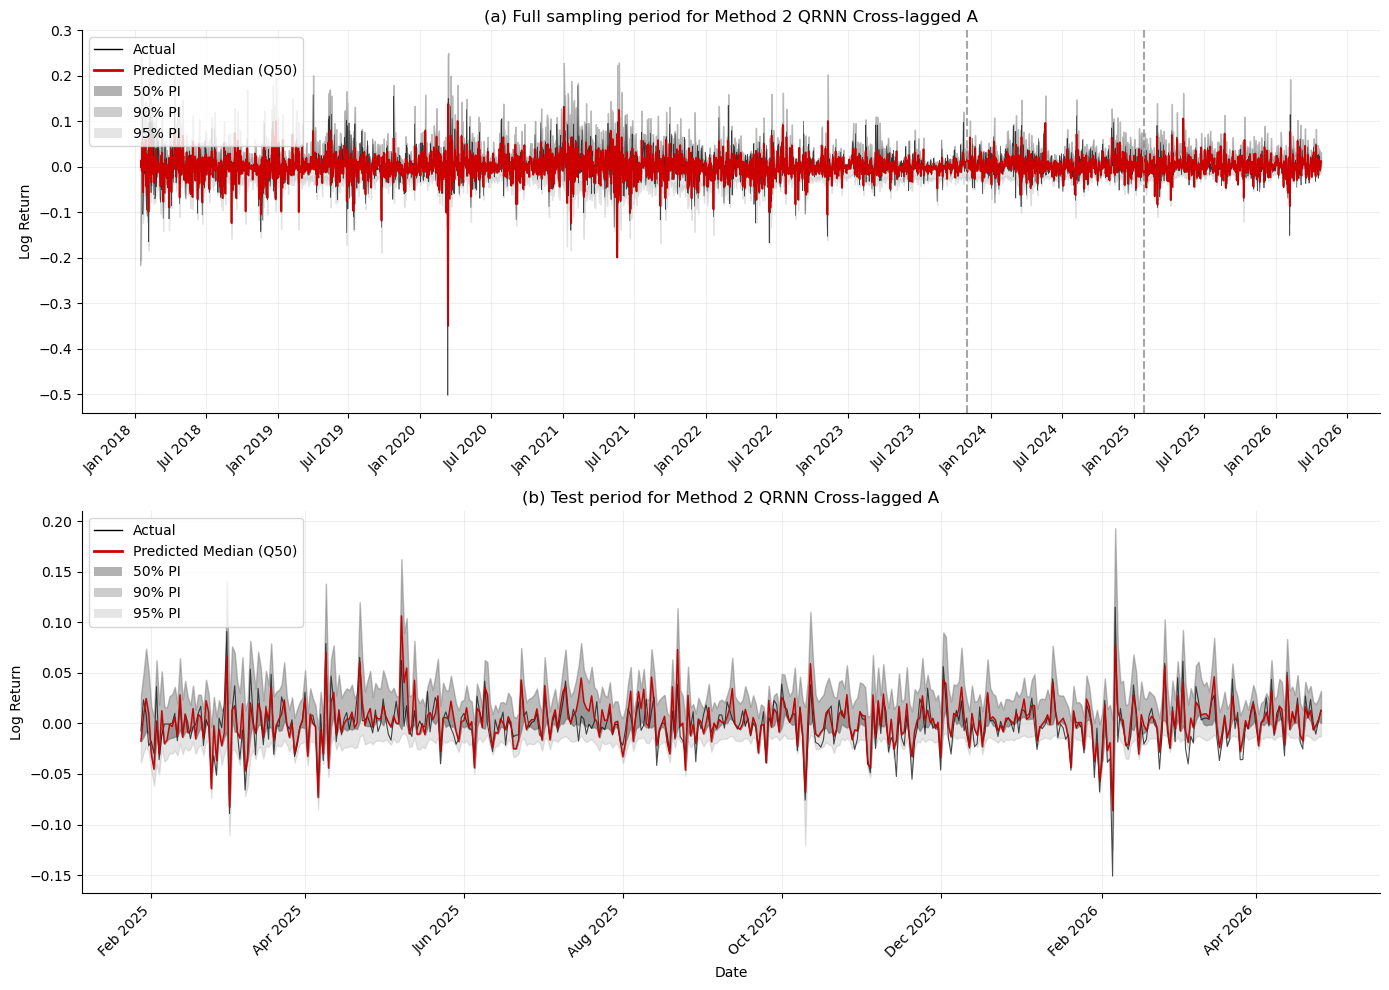

Plot saved to method2_sequential_qrnn_a_cross_predictions.png

TEST METRICS -- METHOD 2 QRNN A CROSS-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -1.993291  0.074890 0.049890
 0.050 -1.577009  0.374449 0.324449
 0.250 -2.657372  0.374449 0.124449
 0.500 -2.840147  0.594714 0.094714
 0.750 -2.730422  0.594714 0.155286
 0.950 -2.221381  0.995595 0.045595
 0.975 -2.317473  0.995595 0.020595

Average NLL: -2.333871
Average HRE: 0.116425

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

Metrics saved to method2_sequential_qrnn_a_cross_test_metrics.csv


In [35]:
# ============================================================
# Corrected plotting code
# Method 2 Sequential QRNN A Cross-lagged
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# Load models only if they are no longer in memory
# ============================================================

if 'm2_cross_best_models' not in globals():
    print(
        'Models not found in memory. '
        'Loading saved checkpoint...'
    )

    m2_cross_loaded_checkpoint = torch.load(
        'method2_sequential_qrnn_a_cross_best.pt',
        map_location='cpu',
        weights_only=False
    )

    m2_cross_best_models = {}

    for alpha in (
        m2_cross_loaded_checkpoint[
            'estimation_order'
        ]
    ):
        saved_information = (
            m2_cross_loaded_checkpoint[
                'models'
            ][str(alpha)]
        )

        model = M2SequentialQRNNCrossA(
            input_dim=X_train.shape[1],
            config=saved_information[
                'config'
            ],
            direction=saved_information[
                'direction'
            ]
        )

        model.load_state_dict(
            saved_information[
                'model_state_dict'
            ]
        )

        model.eval()

        m2_cross_best_models[
            alpha
        ] = model


# ============================================================
# Full-sample tensors
# ============================================================

m2_cross_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

m2_cross_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)


# ============================================================
# Generate all levels sequentially
# Uses the actual fitted model forward function
# ============================================================

m2_cross_all_predictions = {}
m2_cross_all_caviar = {}
m2_cross_all_raw_fnn = {}
m2_cross_all_constrained_fnn = {}
m2_cross_all_sigma = {}

for alpha in m2_cross_estimation_order:
    model = m2_cross_best_models[
        alpha
    ]

    reference_alpha = (
        m2_cross_reference_level[
            alpha
        ]
    )

    if reference_alpha is None:
        reference_prediction = None
    else:
        reference_prediction = (
            m2_cross_all_predictions[
                reference_alpha
            ]
        )

    model.eval()

    with torch.no_grad():
        (
            q_prediction,
            q_caviar,
            raw_fnn,
            constrained_fnn,
            sigma
        ) = model(
            y=m2_cross_y_all,
            X=m2_cross_X_all,
            q_reference=reference_prediction
        )

    m2_cross_all_predictions[
        alpha
    ] = q_prediction.detach()

    m2_cross_all_caviar[
        alpha
    ] = q_caviar.detach()

    m2_cross_all_raw_fnn[
        alpha
    ] = raw_fnn.detach()

    m2_cross_all_constrained_fnn[
        alpha
    ] = constrained_fnn.detach()

    m2_cross_all_sigma[
        alpha
    ] = sigma.detach()


m2_cross_all_preds_np = {
    alpha: prediction.cpu().numpy()
    for alpha, prediction
    in m2_cross_all_predictions.items()
}


# ============================================================
# Sample information
# ============================================================

m2_cross_train_size = len(
    train_df
)

m2_cross_val_size = len(
    val_df
)

m2_cross_test_start = (
    m2_cross_train_size
    + m2_cross_val_size
)

m2_cross_all_dates = df.index
m2_cross_test_dates = test_df.index

m2_cross_y_all_np = (
    df['log_return'].values
)

m2_cross_y_test_np = (
    test_df['log_return'].values
)


# ============================================================
# Plot
# ============================================================

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'

legend_elements = [
    Line2D(
        [0], [0],
        color=actual_color,
        linewidth=1,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=median_color,
        linewidth=2,
        label='Predicted Median (Q50)'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.60,
        label='50% PI'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.40,
        label='90% PI'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.20,
        label='95% PI'
    )
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)


# ============================================================
# Panel (a): full sample
# ============================================================

ax = axes[0]

ax.plot(
    m2_cross_all_dates,
    m2_cross_y_all_np,
    color=actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    m2_cross_all_dates,
    m2_cross_all_preds_np[0.500],
    color=median_color,
    linewidth=1.2
)

ax.fill_between(
    m2_cross_all_dates,
    m2_cross_all_preds_np[0.025],
    m2_cross_all_preds_np[0.975],
    color=interval_color,
    alpha=0.20
)

ax.fill_between(
    m2_cross_all_dates,
    m2_cross_all_preds_np[0.050],
    m2_cross_all_preds_np[0.950],
    color=interval_color,
    alpha=0.40
)

ax.fill_between(
    m2_cross_all_dates,
    m2_cross_all_preds_np[0.250],
    m2_cross_all_preds_np[0.750],
    color=interval_color,
    alpha=0.60
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

ax.set_title(
    '(a) Full sampling period for '
    'Method 2 QRNN Cross-lagged A'
)

ax.set_ylabel('Log Return')
ax.grid(True, alpha=0.2)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

ax.legend(
    handles=legend_elements,
    loc='upper left'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# Panel (b): test sample
# ============================================================

ax2 = axes[1]

ax2.plot(
    m2_cross_test_dates,
    m2_cross_y_test_np,
    color=actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    m2_cross_test_dates,
    m2_cross_all_preds_np[0.500][
        m2_cross_test_start:
    ],
    color=median_color,
    linewidth=1.0
)

ax2.fill_between(
    m2_cross_test_dates,
    m2_cross_all_preds_np[0.025][
        m2_cross_test_start:
    ],
    m2_cross_all_preds_np[0.975][
        m2_cross_test_start:
    ],
    color=interval_color,
    alpha=0.20
)

ax2.fill_between(
    m2_cross_test_dates,
    m2_cross_all_preds_np[0.050][
        m2_cross_test_start:
    ],
    m2_cross_all_preds_np[0.950][
        m2_cross_test_start:
    ],
    color=interval_color,
    alpha=0.40
)

ax2.fill_between(
    m2_cross_test_dates,
    m2_cross_all_preds_np[0.250][
        m2_cross_test_start:
    ],
    m2_cross_all_preds_np[0.750][
        m2_cross_test_start:
    ],
    color=interval_color,
    alpha=0.60
)

ax2.set_title(
    '(b) Test period for '
    'Method 2 QRNN Cross-lagged A'
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.grid(True, alpha=0.2)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax2.legend(
    handles=legend_elements,
    loc='upper left'
)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for axis in axes:
    plt.setp(
        axis.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

plt.tight_layout()

m2_cross_plot_name = (
    'method2_sequential_qrnn_a_cross_predictions.png'
)

plt.savefig(
    m2_cross_plot_name,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(
    f'Plot saved to {m2_cross_plot_name}'
)


# ============================================================
# Test metrics
# ============================================================

m2_cross_y_test = (
    m2_cross_y_all[
        m2_cross_test_start:
    ]
)

m2_cross_metric_rows = []

for alpha in m2_cross_alpha_levels:
    q_test = (
        m2_cross_all_predictions[
            alpha
        ][m2_cross_test_start:]
    )

    sigma = (
        m2_cross_all_sigma[
            alpha
        ]
    )

    test_nll = m2_cross_qrnn_loss(
        m2_cross_y_test,
        q_test,
        sigma,
        alpha
    ).item()

    test_hit_rate = (
        m2_cross_y_test
        <= q_test
    ).float().mean().item()

    test_hre = abs(
        test_hit_rate - alpha
    )

    m2_cross_metric_rows.append({
        'alpha': alpha,
        'NLL': test_nll,
        'Hit_Rate': test_hit_rate,
        'HRE': test_hre
    })


m2_cross_metrics_df = pd.DataFrame(
    m2_cross_metric_rows
)

m2_cross_average_nll = (
    m2_cross_metrics_df[
        'NLL'
    ].mean()
)

m2_cross_average_hre = (
    m2_cross_metrics_df[
        'HRE'
    ].mean()
)

print('\n' + '=' * 68)
print(
    'TEST METRICS -- METHOD 2 '
    'QRNN A CROSS-LAGGED'
)
print('=' * 68)

print(
    m2_cross_metrics_df.to_string(
        index=False
    )
)

print(
    f'\nAverage NLL: '
    f'{m2_cross_average_nll:.6f}'
)

print(
    f'Average HRE: '
    f'{m2_cross_average_hre:.6f}'
)


# ============================================================
# Crossover analysis
# ============================================================

m2_cross_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975)
]

m2_cross_tail_pairs = [
    (0.025, 0.050),
    (0.950, 0.975)
]

m2_cross_total = 0
m2_cross_tail_total = 0
m2_cross_crossover_rows = []

print('\n' + '=' * 68)
print(
    'CROSSOVER ANALYSIS -- '
    'FINAL METHOD 2 HYBRID OUTPUT'
)
print('=' * 68)

for lower, upper in m2_cross_pairs:
    lower_test = (
        m2_cross_all_predictions[
            lower
        ][m2_cross_test_start:]
    )

    upper_test = (
        m2_cross_all_predictions[
            upper
        ][m2_cross_test_start:]
    )

    violations = int(
        (
            lower_test
            > upper_test
        ).sum().item()
    )

    rate = (
        violations
        / len(lower_test)
    )

    m2_cross_total += violations

    if (
        lower,
        upper
    ) in m2_cross_tail_pairs:
        m2_cross_tail_total += (
            violations
        )

    m2_cross_crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': violations,
        'Rate': rate
    })

    tail_label = (
        ' <-- TAIL'
        if (
            lower,
            upper
        ) in m2_cross_tail_pairs
        else ''
    )

    print(
        f'({lower:.3f}, {upper:.3f}): '
        f'{violations} '
        f'({100 * rate:.2f}%)'
        f'{tail_label}'
    )


m2_cross_total_rate = (
    m2_cross_total
    / (
        len(m2_cross_y_test)
        * len(m2_cross_pairs)
    )
)

m2_cross_tail_rate = (
    m2_cross_tail_total
    / (
        len(m2_cross_y_test)
        * len(m2_cross_tail_pairs)
    )
)

print(
    f'\nTotal violations: '
    f'{m2_cross_total} '
    f'({100 * m2_cross_total_rate:.2f}%)'
)

print(
    f'Tail violations: '
    f'{m2_cross_tail_total} '
    f'({100 * m2_cross_tail_rate:.2f}%)'
)


# ============================================================
# Save results
# ============================================================

m2_cross_metrics_df.to_csv(
    (
        'method2_sequential_qrnn_a_cross_'
        'test_metrics.csv'
    ),
    index=False
)

pd.DataFrame(
    m2_cross_crossover_rows
).to_csv(
    (
        'method2_sequential_qrnn_a_cross_'
        'crossover.csv'
    ),
    index=False
)

print(
    '\nMetrics saved to '
    'method2_sequential_qrnn_a_cross_'
    'test_metrics.csv'
)

# Cross over dealing 3

In [45]:
"""Method 3, Specification 1: learned-spacing Hybrid QRNN A cross-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

Models
------
QRNN / ERNN x S / A / SI x self-lagged / cross-lagged.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
import itertools
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_all_12_results")

# This notebook estimates the missing Method 3 QRNN A cross-lagged model.
MODELS_TO_RUN = [("qrnn", "a", "cross")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_all_12_validation_summary.csv", index=False
        )
    print("\nAll requested Method 3 models are complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-17 14:23:32,880] A new study created in memory with name: no-name-3a53a37b-40b1-44bd-b7c2-7575852dd677



METHOD 3 SPACING: QRNN A CROSS
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-17 14:23:58,809] Trial 0 finished with value: 1.3075966835021973 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3075966835021973.
[I 2026-08-17 14:24:24,591] Trial 1 finished with value: 0.2624700665473938 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2624700665473938.
[I 2026-08-17 14:24:27,590] Trial 2 finished with value: 1.4286831617355347 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': True, '

[I 2026-08-17 15:44:23,719] A new study created in memory with name: no-name-ffd9cf92-962e-4fe2-820a-d40315370aa6


...

[I 2026-08-17 15:53:52,722] Trial 0 finished with value: 1.9722583293914795 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9722583293914795.
[I 2026-08-17 15:53:53,991] Trial 1 finished with value: 0.7023374438285828 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.7023374438285828.
[I 2026-08-17 15:53:54,707] Trial 2 finished with value: 2.917407274246216 and parameters: {'n_hidden_layers': 2, 'activati

[I 2026-08-17 15:55:09,663] A new study created in memory with name: no-name-471bbd7c-0a79-434c-abcf-d463ed7631b6


Selected trial #53 | val NLL=-2.413005 | calibration=0.971302 | mean delta=0.014523
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-17 15:55:11,207] Trial 0 finished with value: 2.489959239959717 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.489959239959717.
[I 2026-08-17 15:55:12,788] Trial 1 finished with value: 3.3954920768737793 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 2.489959239959717.
[I 2026-08-17 15:55:13,294] Trial 2 finished with value: 3.5396358966827393 and parameters: {'n_hidden_lay

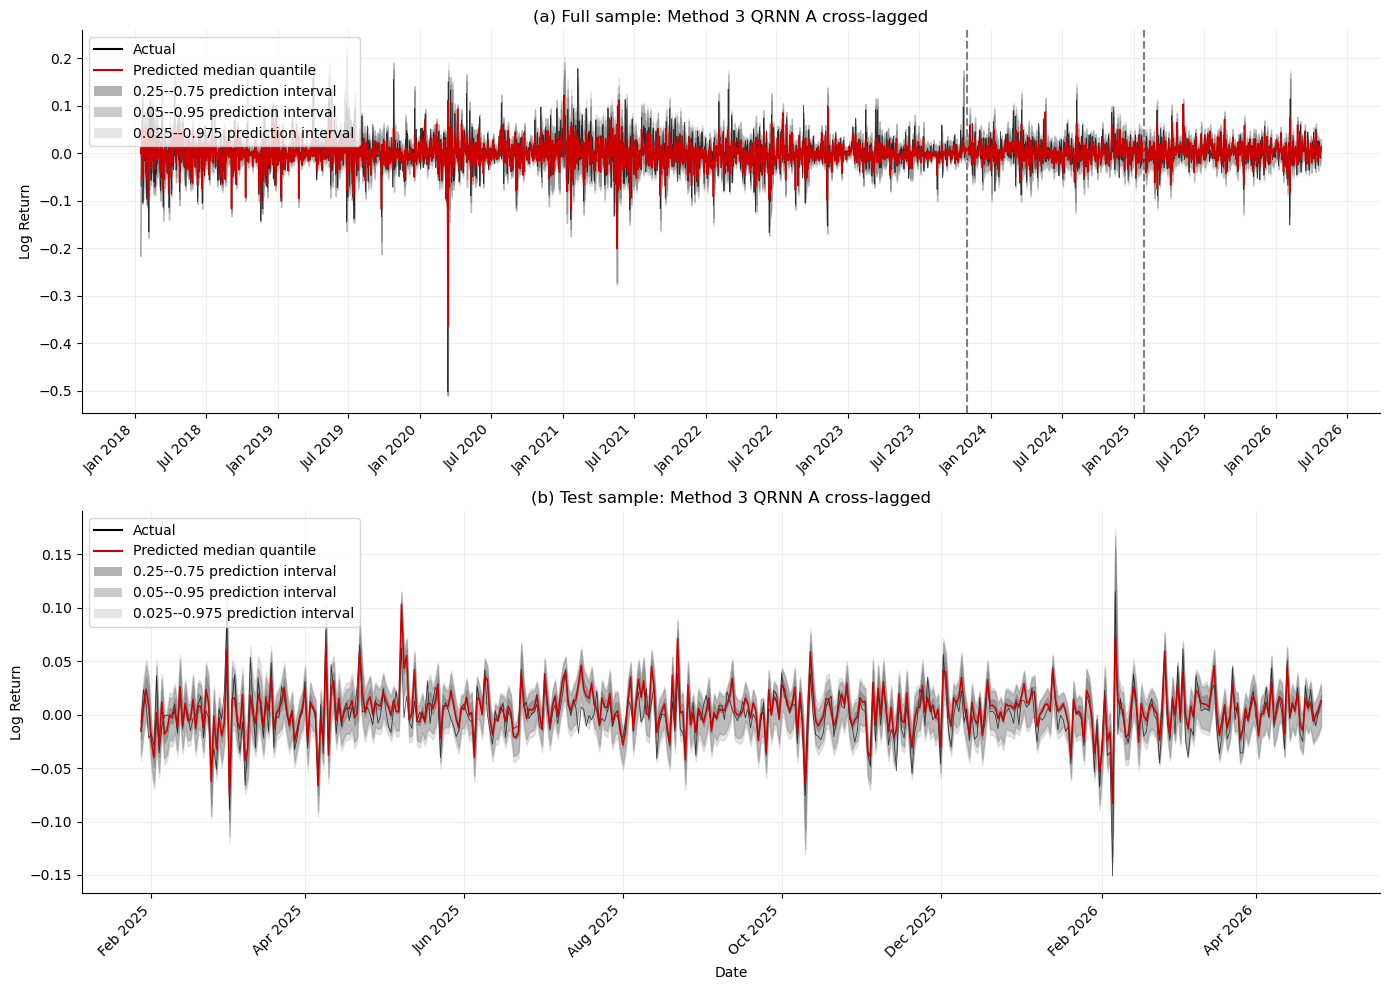


METHOD 3 QRNN A CROSS-LAGGED -- TEST RESULTS
                model  test_T  average_nll  average_hre  crossover  tail
Method 3 QRNN A Cross     454    -2.644109     0.092826          0     0

Per-level results:
 alpha       nll  hit_rate      hre    sigma
 0.025 -2.440951  0.030837 0.005837 0.000905
 0.050 -2.565556  0.063877 0.013877 0.001557
 0.250 -2.581370  0.572687 0.322687 0.004967
 0.500 -2.769404  0.667401 0.167401 0.008389
 0.750 -2.854914  0.850220 0.100220 0.004955
 0.950 -2.697011  0.975771 0.025771 0.001474
 0.975 -2.599555  0.988987 0.013987 0.000874

Learned-spacing diagnostics:
 alpha  reference_alpha direction  mean_delta  min_delta  max_delta  sd_delta  near_zero_count  near_zero_rate
 0.025             0.05     lower    0.005051   0.001421   0.005485  0.000956                0             0.0
 0.050             0.25     lower    0.018588   0.010582   0.026841  0.002134                0             0.0
 0.250             0.50     lower    0.003682   0.000448   0.0407

In [47]:
"""Plot and evaluate Method 3 QRNN A cross-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

MODEL_DIR = Path("method3_spacing_all_12_results") / "qrnn_a_cross"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_qrnn_a_cross_best.pt"
PLOT_PATH = MODEL_DIR / "method3_spacing_qrnn_a_cross.png"
METRICS_PATH = MODEL_DIR / "method3_spacing_qrnn_a_cross_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "method3_spacing_qrnn_a_cross_test_summary.csv"
DELTA_PATH = MODEL_DIR / "method3_spacing_qrnn_a_cross_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "method3_spacing_qrnn_a_cross_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    from method3_spacing_all_12_tuning import Method3SpacingModel

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "qrnn":
    raise ValueError("The checkpoint is not a QRNN checkpoint.")
if checkpoint.get("form") != "a" or checkpoint.get("lag") != "cross":
    raise ValueError("The checkpoint is not the QRNN A cross-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="qrnn",
        form="a",
        lag="cross",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 QRNN A cross-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 QRNN A cross-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median quantile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 prediction interval"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 prediction interval"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 prediction interval"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test ALD NLL, hit rate and HRE
# ---------------------------------------------------------------------------


def ald_nll(y, quantile, sigma, alpha):
    residual = y - quantile
    alpha_tensor = torch.tensor(alpha, dtype=y.dtype, device=y.device)
    indicator = (residual < 0).to(y.dtype)
    check_loss = residual * (alpha_tensor - indicator)
    return (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma)
        + check_loss / sigma
    ).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    hit_rate = (y_test <= prediction_test).float().mean().item()
    metric_rows.append({
        "alpha": level,
        "nll": ald_nll(y_test, prediction_test, sigmas[level], level).item(),
        "hit_rate": hit_rate,
        "hre": abs(hit_rate - level),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "alpha": level,
        "reference_alpha": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 QRNN A Cross",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_hre": metrics_df["hre"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"q_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 QRNN A CROSS-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")